In [54]:
import numpy as np 
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler

In [55]:
X_train = pd.read_csv("../Data/X_train.csv")
X_test = pd.read_csv("../Data/X_test.csv")

y_train = pd.read_csv("../Data/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/y_test.csv").squeeze()


In [ ]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [57]:
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [58]:
y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1,1))

In [59]:
y_train_scaled = y_train_scaled.ravel()

In [60]:
model = LinearRegression()
model.fit(X_train_scaled,y_train_scaled)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0.67,-0.26,-0.27, 0.1 ,-0.21]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.824
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[13.02,12.67, 8.47, 4.83, 3.49]"


In [61]:
y_train_pred_scaled = model.predict(X_train_scaled)
y_test_pred_scaled = model.predict(X_test_scaled)

In [62]:
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1,1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1,1)).ravel()

In [63]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error


In [64]:
r2_test = r2_score(y_test,y_test_pred)
mae_test = mean_absolute_error(y_test,y_test_pred)
mse_test = mean_squared_error(y_test,y_test_pred)
rmse_test = root_mean_squared_error(y_test,y_test_pred)

In [ ]:
print(f"R2:   {r2_test:.3f}")
print(f"MAE:  {mae_test:.3f} dB")
print(f"MSE:  {mse_test:.3f} dB^2")
print(f"RMSE: {rmse_test:.3f} dB")

R²:   0.545
MAE:  3.692 dB
MSE:  22.534 dB²
RMSE: 4.747 dB


In [66]:
r2_train = r2_score(y_train,y_train_pred)
mae_train = mean_absolute_error(y_train,y_train_pred)
mse_train = mean_squared_error(y_train,y_train_pred)
rmse_train = root_mean_squared_error(y_train,y_train_pred)

In [ ]:
print(f"R2:   {r2_train:.3f}")
print(f"MAE:  {mae_train:.3f} dB")
print(f"MSE:  {mse_train:.3f} dB^2")
print(f"RMSE: {rmse_train:.3f} dB")

R²:   0.501
MAE:  3.764 dB
MSE:  23.314 dB²
RMSE: 4.828 dB


In [68]:
results = pd.DataFrame({
    "Metric": ["R2","MAE","MSE","RMSE"],
    "Train": [r2_train,mae_train,mse_train,rmse_train],
    "Test": [r2_test,mae_test,mse_test,rmse_test]
})

results

,Metric,Train,Test
0,R2,0.500599,0.545468
1,MAE,3.763575,3.691696
2,MSE,23.313983,22.533631
3,RMSE,4.828456,4.746960


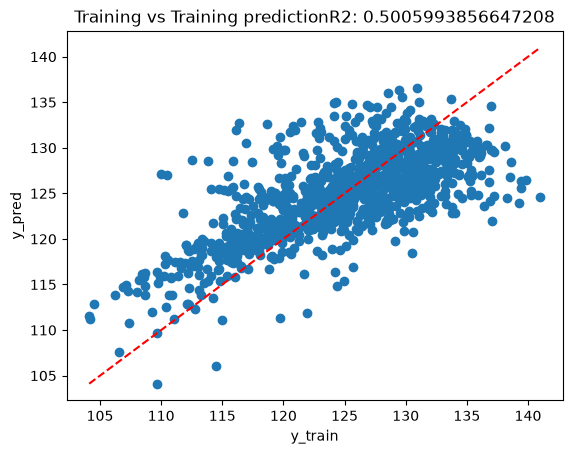

In [69]:
import matplotlib. pyplot as plt 

plt.scatter(y_train,y_train_pred)
plt.xlabel("y_train")
plt.ylabel("y_pred")
plt.title("Training vs Training prediction" 'R2: ' + str(r2_train))

low = min(y_train.min(), y_train_pred.min())
high = max(y_train.max(), y_train_pred.max())

plt.plot([low, high], [low, high], linestyle="--",color="red")


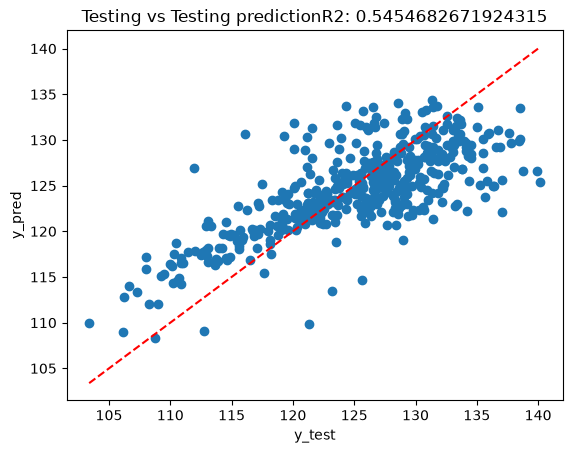

In [70]:

plt.scatter(y_test,y_test_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.title("Testing vs Testing prediction" 'R2: ' + str(r2_test))

low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())

plt.plot([low, high], [low, high], linestyle="--",color="red")


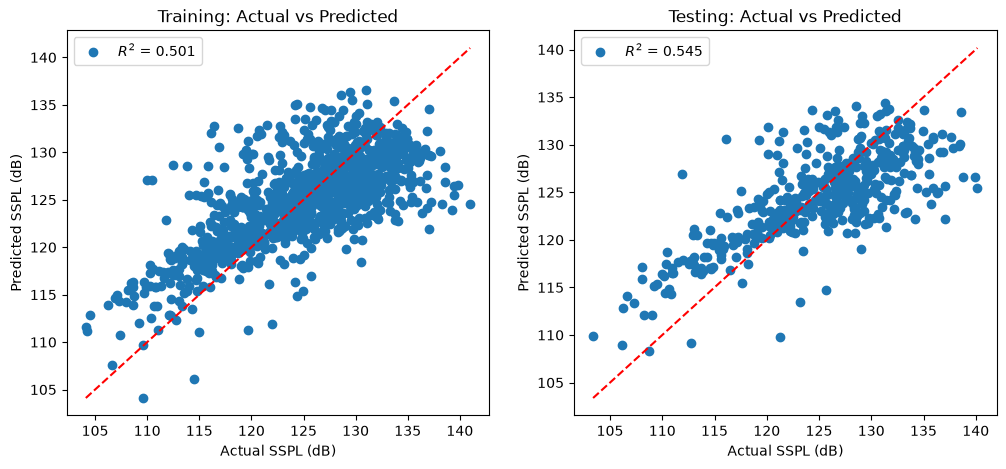

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_train, y_train_pred,label=f"$R^2$ = {r2_train:.3f}")
ax2.scatter(y_test, y_test_pred , label=f"$R^2$ = {r2_test:.3f}")

ax1.set_xlabel("Actual SSPL (dB)")
ax1.set_ylabel("Predicted SSPL (dB)")
ax1.set_title("Training: Actual vs Predicted")

low = min(y_train.min(), y_train_pred.min())
high = max(y_train.max(), y_train_pred.max())


ax1.plot([low, high], [low, high], linestyle="--", color="red")

ax2.set_xlabel("Actual SSPL (dB)")
ax2.set_ylabel("Predicted SSPL (dB)")
ax2.set_title("Testing: Actual vs Predicted")

low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())

ax2.plot([low, high], [low, high], linestyle="--", color="red")

ax1.legend()
ax2.legend()

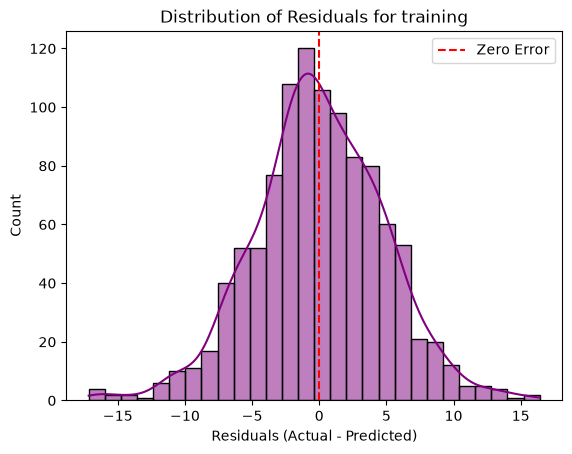

In [72]:
import seaborn as sns 
train_residuals = y_train - y_train_pred
sns.histplot(train_residuals,kde=True,color="purple")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error") # reference line
plt.title("Distribution of Residuals for training")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.show()

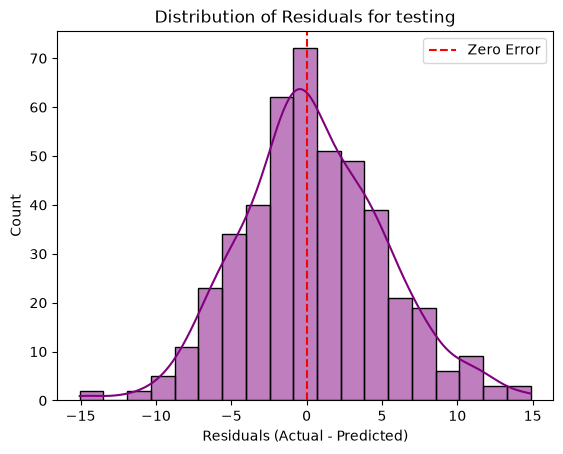

In [73]:
import seaborn as sns 
test_residuals = y_test - y_test_pred
sns.histplot(test_residuals,kde=True,color="purple")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error") # reference line
plt.title("Distribution of Residuals for testing")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.show()

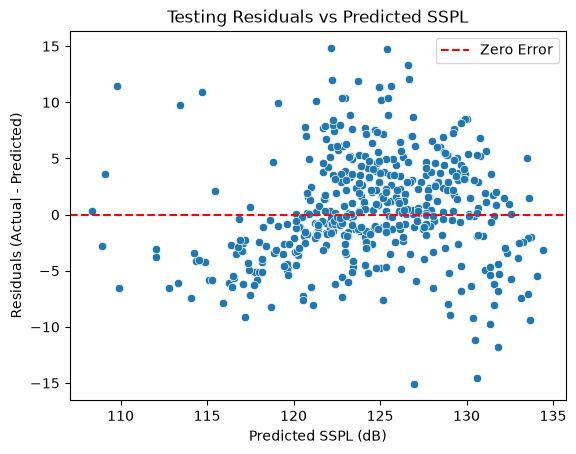

In [74]:
test_residuals = y_test - y_test_pred

sns.scatterplot(
    x=y_test_pred,
    y=test_residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="Zero Error"
)

plt.title("Testing Residuals vs Predicted SSPL")
plt.xlabel("Predicted SSPL (dB)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.show()

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

X_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("regression", LinearRegression())
])

model_cv = TransformedTargetRegressor(
    regressor=X_pipeline,
    transformer=MinMaxScaler()
)

scores = cross_validate(
    model_cv,
    X_train,
    y_train,
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error"
    ),
    return_train_score=True
)

scores

{'fit_time': array([0.00549364, 0.00478888, 0.0041945 , 0.00416732, 0.00416183]),
 'score_time': array([0.00333047, 0.00324607, 0.00311565, 0.00316525, 0.00326514]),
 'test_r2': array([0.51142456, 0.41296425, 0.54405353, 0.47287926, 0.46452969]),
 'train_r2': array([0.49512383, 0.5129078 , 0.48691477, 0.50574387, 0.50754536]),
 'test_neg_mean_absolute_error': array([-3.74249301, -3.77085375, -3.87027488, -3.78557196, -3.85409068]),
 'train_neg_mean_absolute_error': array([-3.77158664, -3.76706041, -3.76882976, -3.75197904, -3.73416951]),
 'test_neg_mean_squared_error': array([-23.15391676, -23.64691911, -21.92702898, -25.20311046,
        -25.58008377]),
 'train_neg_mean_squared_error': array([-23.43187852, -23.31963417, -23.76032747, -22.9054443 ,
        -22.82588164]),
 'test_neg_root_mean_squared_error': array([-4.8118517 , -4.8628098 , -4.68263056, -5.02026996, -5.05767573]),
 'train_neg_root_mean_squared_error': array([-4.84064856, -4.82904071, -4.87445663, -4.78596326, -4.777643

In [76]:
cross_val_results = pd.DataFrame(scores)
cross_val_results

,fit_time,score_time,test_r2,train_r2,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
0,0.005494,0.003330,0.511425,0.495124,-3.742493,-3.771587,-23.153917,-23.431879,-4.811852,-4.840649
1,0.004789,0.003246,0.412964,0.512908,-3.770854,-3.767060,-23.646919,-23.319634,-4.862810,-4.829041
2,0.004194,0.003116,0.544054,0.486915,-3.870275,-3.768830,-21.927029,-23.760327,-4.682631,-4.874457
3,0.004167,0.003165,0.472879,0.505744,-3.785572,-3.751979,-25.203110,-22.905444,-5.020270,-4.785963
4,0.004162,0.003265,0.464530,0.507545,-3.854091,-3.734170,-25.580084,-22.825882,-5.057676,-4.777644


In [77]:
summary_results = pd.DataFrame({
    "Mean": cross_val_results.mean(),
    "Std": cross_val_results.std()
})

summary_results

,Mean,Std
fit_time,0.004561,0.000585
score_time,0.003225,0.000085
test_r2,0.481170,0.049667
train_r2,0.501647,0.010464
test_neg_mean_absolute_error,-3.804657,0.055047
train_neg_mean_absolute_error,-3.758725,0.015696
test_neg_mean_squared_error,-23.902212,1.502836
train_neg_mean_squared_error,-23.248633,0.386312
test_neg_root_mean_squared_error,-4.887048,0.154021
train_neg_root_mean_squared_error,-4.821551,0.040044


In [78]:
# import sklearn
# sklearn.metrics.get_scorer_names()